In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
from collections import Counter



### Loading the raw dataset

In [ ]:
RAW_DATA_PATH = "../data/raw/best_book_ever_dataset.csv"

df_raw = pd.read_csv(RAW_DATA_PATH, encoding='utf-8')
print(f"\nDataset loaded successfully!")
print(f"   - Total rows: {df_raw.shape[0]:,}")
print(f"   - Total columns: {df_raw.shape[1]}")




Dataset loaded successfully!
   - Total rows: 52,478
   - Total columns: 25


### Initial Data Exploration

In [ ]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print("\nBasic Information:")
print(f"Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

print("\n" + "-"*80)
print("Column Names:")
print(df_raw.columns.tolist())

print("\n" + "-"*80)
print(" Data Types and Non-Null Counts:")
print(df_raw.info())




DATASET OVERVIEW

Basic Information:
Shape: (52478, 25)
Rows: 52,478
Columns: 25

--------------------------------------------------------------------------------
Column Names:
['bookId', 'title', 'series', 'author', 'rating', 'description', 'language', 'isbn', 'genres', 'characters', 'bookFormat', 'edition', 'pages', 'publisher', 'publishDate', 'firstPublishDate', 'awards', 'numRatings', 'ratingsByStars', 'likedPercent', 'setting', 'coverImg', 'bbeScore', 'bbeVotes', 'price']

--------------------------------------------------------------------------------
 Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  object 
 1   title             52478 non-null  object 
 2   series            23470 non-null  object 
 3   author            52478 non-null  object 
 4   rating 

### Analysis of Missing Values 

MISSING VALUES ANALYSIS

 Columns with Missing Values:
          Column  Missing_Count  Missing_Percentage
         edition          47523           90.557948
          series          29008           55.276497
firstPublishDate          21326           40.637982
           price          14365           27.373376
        language           3806            7.252563
       publisher           3696            7.042951
           pages           2347            4.472350
      bookFormat           1473            2.806891
     description           1338            2.549640
     publishDate            880            1.676893
    likedPercent            622            1.185259
        coverImg            605            1.152864


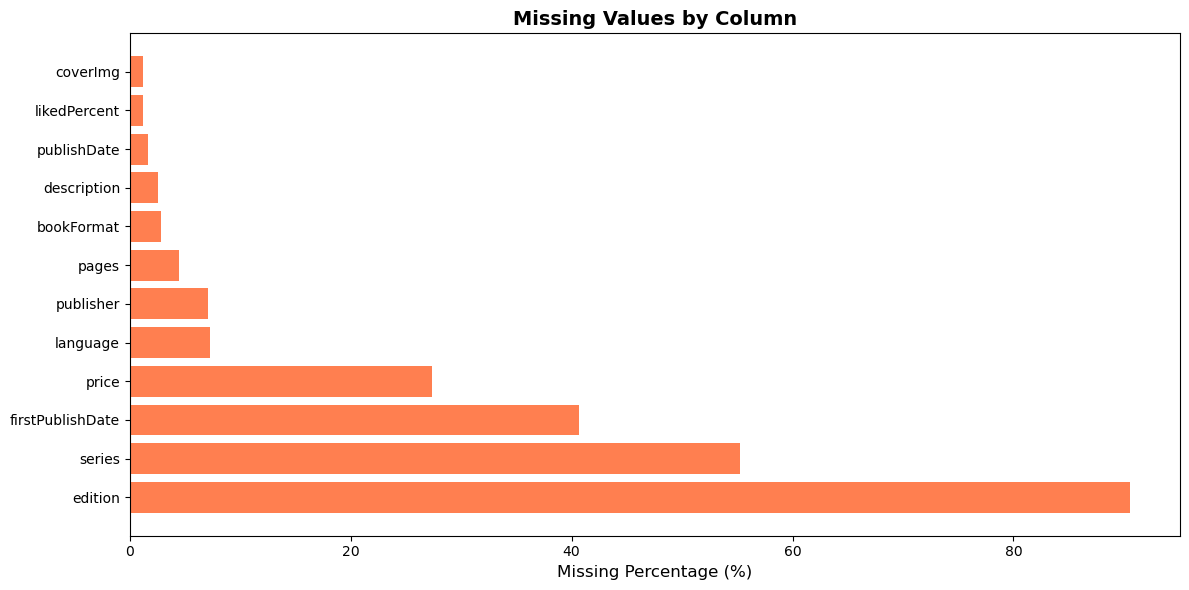

In [20]:

print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

# Counts missing values per column
missing_counts = df_raw.isnull().sum()
missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100

# Creates a summary dataframe
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

# Filters to show only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

print("\n Columns with Missing Values:")
if len(missing_df) == 0:
    print("No missing values found!")
else:
    print(missing_df.to_string(index=False))

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Column'], missing_df['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

###  Key Columns Check 


In [ ]:

print("=" * 80)
print("KEY COLUMNS EXAMINATION")
print("=" * 80)

# Expected column names
DESCRIPTION_COL = "description"
GENRE_COL = "genres"

# Checks description column
if DESCRIPTION_COL in df_raw.columns:
    print("\nDESCRIPTION COLUMN ANALYSIS")
    print(f"   - Column name: '{DESCRIPTION_COL}'")
    print(f"   - Data type: {df_raw[DESCRIPTION_COL].dtype}")
    print(f"   - Missing values: {df_raw[DESCRIPTION_COL].isnull().sum()} "
          f"({df_raw[DESCRIPTION_COL].isnull().sum() / len(df_raw) * 100:.2f}%)")
    
    print("\n   Sample descriptions:")
    for i, desc in enumerate(df_raw[DESCRIPTION_COL].dropna().head(3), 1):
        print(f"\n   Example {i}:")
        print(f"   {str(desc)[:200]}...")

else:
    print("\n'description' column not found")

# Check genre column
if GENRE_COL in df_raw.columns:
    print("\nGENRE COLUMN ANALYSIS")
    print(f"   - Column name: '{GENRE_COL}'")
    print(f"   - Data type: {df_raw[GENRE_COL].dtype}")
    print(f"   - Missing values: {df_raw[GENRE_COL].isnull().sum()} "
          f"({df_raw[GENRE_COL].isnull().sum() / len(df_raw) * 100:.2f}%)")

    print("\n   Sample genres:")
    for i, genre in enumerate(df_raw[GENRE_COL].dropna().head(5), 1):
        print(f"   {i}. {genre}")

else:
    print("\n'genre' column not found")


KEY COLUMNS EXAMINATION

DESCRIPTION COLUMN ANALYSIS
   - Column name: 'description'
   - Data type: object
   - Missing values: 1338 (2.55%)

   Sample descriptions:

   Example 1:
   WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place once known as North America lies the nation of Panem, a shining Capitol surrounded b...

   Example 2:
   There is a door at the end of a silent corridor. And it’s haunting Harry Pottter’s dreams. Why else would he be waking in the middle of the night, screaming in terror?Harry has a lot on his mind for t...

   Example 3:
   The unforgettable novel of a childhood in a sleepy Southern town and the crisis of conscience that rocked it, To Kill A Mockingbird became both an instant bestseller and a critical success when it was...

GENRE COLUMN ANALYSIS
   - Column name: 'genres'
   - Data type: object
   - Missing values: 0 (0.00%)

   Sample genres:
   1. ['Young Adult', 'Fiction', 'Dystopia',

### Cleaning Text Description 

In [ ]:
def clean_text(text):
    """
    Clean a single text description

    Args:
        text: Raw text string
        
    Returns:
        Cleaned text string
    """
    
    # Step 1: Handles missing values
    if pd.isna(text):
        return ""
    
    # Step 2: Converts to string (in case it's not)
    text = str(text)
    
    # Step 3: Removes HTML tags
    # Pattern: <anything> becomes empty
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 4: Removes HTML entities
    # Pattern: &word; becomes space
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)
    text = re.sub(r'&#\d+;', ' ', text)
    
    # Step 5: Removes URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Step 6: Keep sonly letters, numbers, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\'\"\-\:\;]', ' ', text)
    
    # Step 7: Normalizes whitespace (multiple spaces → one space)
    text = re.sub(r'\s+', ' ', text)
    
    # Step 8: Strip leading/trailing spaces
    text = text.strip()
    
    return text

In [26]:
# Applying cleaning function

# Creates a copy of the dataframe for processing
df = df_raw.copy()

# Cleans the description column
df['description_clean'] = df[DESCRIPTION_COL].apply(clean_text)

# Shows before/after examples
print("="*80)
print("CLEANING RESULTS")
print("="*80)

print("\nStatistics:")
print(f"   Original descriptions: {df[DESCRIPTION_COL].notna().sum()}")
print(f"   After cleaning: {(df['description_clean'] != '').sum()}")
print(f"   Empty after cleaning: {(df['description_clean'] == '').sum()}")

# Calculates description lengths
df['description_length'] = df['description_clean'].str.len()

print(f"\n Description Length Statistics:")
print(f"   Mean length: {df['description_length'].mean():.2f} characters")
print(f"   Median length: {df['description_length'].median():.2f} characters")
print(f"   Min length: {df['description_length'].min()} characters")
print(f"   Max length: {df['description_length'].max()} characters")

# Shows before/after comparison
print("\n" + "="*80)
print("BEFORE vs AFTER EXAMPLES")
print("="*80)

for i in range(2):
    sample = df[df[DESCRIPTION_COL].notna()].iloc[i]
    print(f"\nExample {i+1}:")
    print(f"\n BEFORE (first 300 chars):")
    print(sample[DESCRIPTION_COL][:300])
    print(f"\n AFTER (first 300 chars):")
    print(sample['description_clean'][:300])
    print("-"*80)

CLEANING RESULTS

Statistics:
   Original descriptions: 51140
   After cleaning: 50986
   Empty after cleaning: 1492

 Description Length Statistics:
   Mean length: 817.10 characters
   Median length: 766.00 characters
   Min length: 0 characters
   Max length: 23313 characters

BEFORE vs AFTER EXAMPLES

Example 1:

 BEFORE (first 300 chars):
WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place once known as North America lies the nation of Panem, a shining Capitol surrounded by twelve outlying districts. The Capitol is harsh and cruel and keeps the districts in line by forci

 AFTER (first 300 chars):
WINNING MEANS FAME AND FORTUNE.LOSING MEANS CERTAIN DEATH.THE HUNGER GAMES HAVE BEGUN. . . .In the ruins of a place once known as North America lies the nation of Panem, a shining Capitol surrounded by twelve outlying districts. The Capitol is harsh and cruel and keeps the districts in line by forci
-------------------------

### Removing Short/Empty Descriptions

In [28]:
print("="*80)
print("FILTERING SHORT DESCRIPTIONS")
print("="*80)

# Defining minimum length threshold
MIN_DESCRIPTION_LENGTH = 20

print(f"\nMinimum description length: {MIN_DESCRIPTION_LENGTH} characters")

# Counting descriptions by length category
total_before = len(df)
empty = (df['description_clean'] == '').sum()
too_short = ((df['description_clean'].str.len() > 0) & 
             (df['description_clean'].str.len() < MIN_DESCRIPTION_LENGTH)).sum()
valid = (df['description_clean'].str.len() >= MIN_DESCRIPTION_LENGTH).sum()

print(f"\nDescription Categories:")
print(f"   Empty descriptions: {empty} ({empty/total_before*100:.2f}%)")
print(f"   Too short (< {MIN_DESCRIPTION_LENGTH} chars): {too_short} ({too_short/total_before*100:.2f}%)")
print(f"   Valid descriptions: {valid} ({valid/total_before*100:.2f}%)")

# Filtering dataset
df = df[df['description_clean'].str.len() >= MIN_DESCRIPTION_LENGTH].copy()

print(f"\nFiltering complete:")
print(f"   Before: {total_before:,} books")
print(f"   After: {len(df):,} books")
print(f"   Removed: {total_before - len(df):,} books ({(total_before - len(df))/total_before*100:.2f}%)")

# Reseting index
df = df.reset_index(drop=True)

FILTERING SHORT DESCRIPTIONS

Minimum description length: 20 characters

Description Categories:
   Empty descriptions: 0 (0.00%)
   Too short (< 20 chars): 0 (0.00%)
   Valid descriptions: 50201 (100.00%)

Filtering complete:
   Before: 50,201 books
   After: 50,201 books
   Removed: 0 books (0.00%)


### Exploring All Genres in Dataset

In [36]:
print("="*80)
print("ANALYZING ALL GENRES IN DATASET")
print("="*80)

# Function to extract all unique genres
def extract_all_genres(genre_field):
    """Extract all unique genre terms from the dataset"""
    if pd.isna(genre_field):
        return []
    
    genre_str = str(genre_field).lower()
    
    # Spliting by common separators
    # Genres might be: "Fiction, Mystery" or "['Fiction', 'Mystery']"
    genres = re.split(r'[,\[\]\'\"]', genre_str)
    
    # Cleaning and filter
    genres = [g.strip() for g in genres if g.strip() and len(g.strip()) > 2]
    
    return genres


# Extracting all genres from all books
print("\n Extracting all genre terms from dataset...")
all_genres = []
for genres in df[GENRE_COL]:
    all_genres.extend(extract_all_genres(genres))

# Counting frequency
genre_frequency = Counter(all_genres)

# Showing top 50 most common genres
print("\nTop 50 Most Common Genre Terms:")
print("-"*80)
for idx, (genre, count) in enumerate(genre_frequency.most_common(50), 1):
    print(f"{idx:2d}. {genre:30s} : {count:6,} books")

# Searching for our target genres (with variations)
print("\n" + "="*80)
print("SEARCHING FOR TARGET GENRES")
print("="*80)

target_search = {
    'Fiction': ['fiction'],
    'Mystery': ['mystery', 'mysteries', 'detective', 'crime'],
    'Romance': ['romance', 'romantic'],
    'Science Fiction': ['science fiction', 'sci-fi', 'scifi', 'sf', 'science-fiction'],
    'Fantasy': ['fantasy', 'fantastical'],
    'Horror': ['horror', 'scary', 'terror'],
    'Biography': ['biography', 'biographies', 'autobiography', 'memoir'],
    'Self-Help': ['self-help', 'self help', 'selfhelp', 'personal development', 
                  'self improvement', 'motivational']
}

print("\n🔎 Searching for genre variations...")
for target_genre, search_terms in target_search.items():
    print(f"\n{target_genre}:")
    found = []
    for term in search_terms:
        if term in genre_frequency:
            found.append(f" '{term}': {genre_frequency[term]:,} books")
    
    if found:
        for f in found:
            print(f)
    else:
        print(f" No matches found")

ANALYZING ALL GENRES IN DATASET

 Extracting all genre terms from dataset...

Top 50 Most Common Genre Terms:
--------------------------------------------------------------------------------
 1. fiction                        : 30,971 books
 2. romance                        : 15,322 books
 3. fantasy                        : 14,863 books
 4. young adult                    : 11,625 books
 5. contemporary                   : 10,376 books
 6. adult                          :  8,209 books
 7. nonfiction                     :  7,882 books
 8. mystery                        :  7,636 books
 9. historical fiction             :  7,539 books
10. novels                         :  7,358 books
11. audiobook                      :  7,226 books
12. classics                       :  6,529 books
13. adventure                      :  6,349 books
14. historical                     :  6,279 books
15. paranormal                     :  5,961 books
16. literature                     :  5,378 books
17. scien

### Genre Extraction

GENRE EXTRACTION (IMPROVED)
\Target Genres:
   1. Fiction
   2. Mystery
   3. Romance
   4. Science Fiction
   5. Fantasy
   6. Horror
   7. Biography
   8. Self-Help

Extracting primary genres

Extraction Results:
   Total books: 44,418
   Books with target genre: 44,418 (100.00%)
   Books without target genre: 0 (0.00%)

Genre Distribution (After Improved Extraction):
primary_genre
Fiction            11037
Romance             7699
Fantasy             7023
Mystery             5711
Science Fiction     5683
Biography           3207
Horror              2820
Self-Help           1238
Name: count, dtype: int64

 Distribution Percentages:
   Fiction             : 11,037 books (24.85%)
   Mystery             :  5,711 books (12.86%)
   Romance             :  7,699 books (17.33%)
   Science Fiction     :  5,683 books (12.79%)
   Fantasy             :  7,023 books (15.81%)
   Horror              :  2,820 books ( 6.35%)
   Biography           :  3,207 books ( 7.22%)
   Self-Help           :  1,23

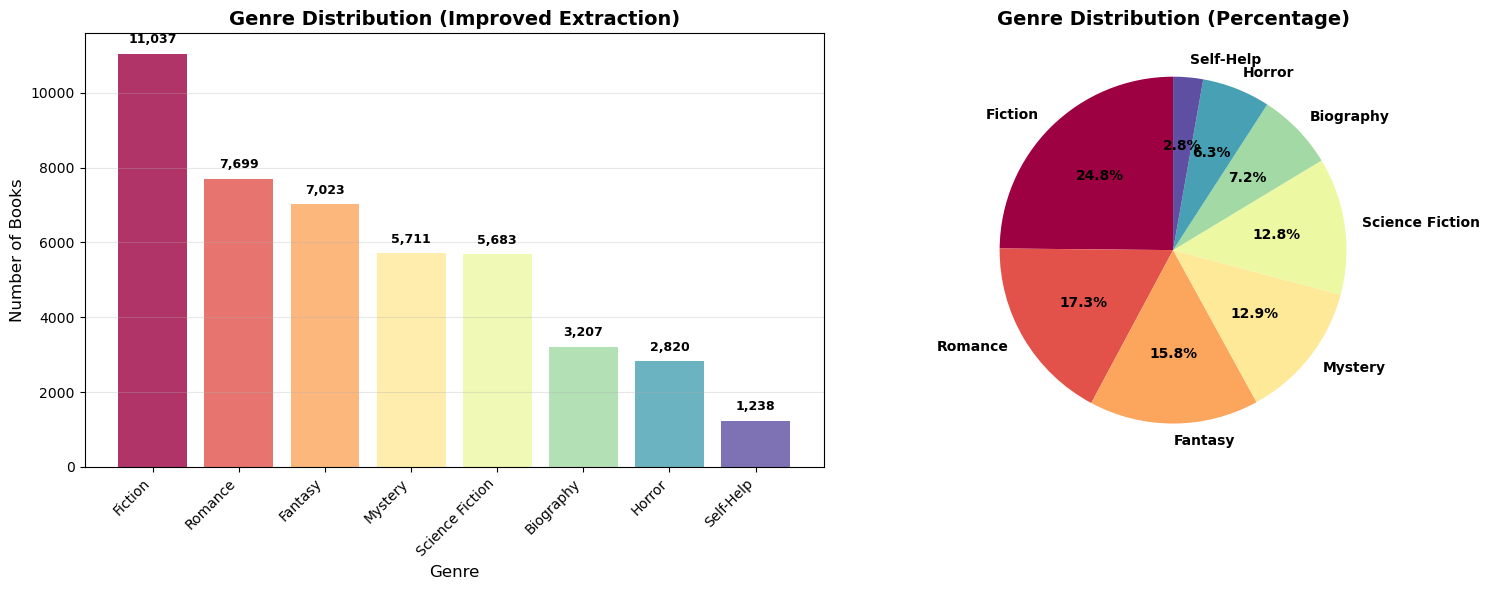


Filtering complete:
   Books remaining: 44,418
   Books removed: 0

All 8 target genres present!


In [ ]:
print("="*80)
print("GENRE EXTRACTION (IMPROVED)")
print("="*80)

# Defining  our 8 target genres
TARGET_GENRES = [
    'Fiction',
    'Mystery', 
    'Romance',
    'Science Fiction',
    'Fantasy',
    'Horror',
    'Biography',
    'Self-Help'
]

print("\Target Genres:")
for i, genre in enumerate(TARGET_GENRES, 1):
    print(f"   {i}. {genre}")

def extract_primary_genre_improved(genre_field):
    """
    Extract primary genre with priority-based matching
    
    Args:
        genre_field: Genre string from dataset
        
    Returns:
        Primary genre name or None
    """
    if pd.isna(genre_field):
        return None
    
    genre_str = str(genre_field).lower()
    
    # PRIORITY 1: Self-Help (RAREST )
    self_help_terms = ['self-help', 'self help', 'selfhelp', 'personal development', 
                       'self improvement', 'motivational']
    for term in self_help_terms:
        if term in genre_str:
            return 'Self-Help'
    
    # PRIORITY 2: Biography (includes autobiography, memoir)
    bio_terms = ['biography', 'autobiography', 'memoir']
    for term in bio_terms:
        if term in genre_str:
            return 'Biography'
    
    # PRIORITY 3: Horror
    if 'horror' in genre_str:
        return 'Horror'
    
    # PRIORITY 4: Science Fiction
    sci_fi_terms = ['science fiction', 'sci-fi', 'scifi', 'science-fiction', 'sci fi']
    for term in sci_fi_terms:
        if term in genre_str:
            return 'Science Fiction'
    
    # PRIORITY 5: Mystery (includes detective, crime)
    mystery_terms = ['mystery', 'detective', 'crime fiction']
    for term in mystery_terms:
        if term in genre_str:
            return 'Mystery'
    
    # PRIORITY 6: Fantasy
    if 'fantasy' in genre_str:
        return 'Fantasy'
    
    # PRIORITY 7: Romance
    if 'romance' in genre_str:
        return 'Romance'
    
    # PRIORITY 8: Fiction (MOST COMMON )
    if 'fiction' in genre_str:
        return 'Fiction'
    
    return None  # No target genre found

# Applying  genre extraction
print("\nExtracting primary genres")
df['primary_genre'] = df[GENRE_COL].apply(extract_primary_genre_improved)

# Analyzing extraction results
total = len(df)
with_genre = df['primary_genre'].notna().sum()
without_genre = df['primary_genre'].isna().sum()

print(f"\nExtraction Results:")
print(f"   Total books: {total:,}")
print(f"   Books with target genre: {with_genre:,} ({with_genre/total*100:.2f}%)")
print(f"   Books without target genre: {without_genre:,} ({without_genre/total*100:.2f}%)")

# Showing genre distribution BEFORE filtering
print(f"\nGenre Distribution (After Improved Extraction):")
genre_dist = df['primary_genre'].value_counts().sort_values(ascending=False)
print(genre_dist)

# Calculating distribution percentages
print(f"\n Distribution Percentages:")
for genre in TARGET_GENRES:
    count = genre_dist.get(genre, 0)
    pct = (count / with_genre * 100) if with_genre > 0 else 0
    print(f"   {genre:20s}: {count:6,} books ({pct:5.2f}%)")

# Visualizing distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.Spectral(np.linspace(0, 1, len(genre_dist)))
axes[0].bar(range(len(genre_dist)), genre_dist.values, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(genre_dist)))
axes[0].set_xticklabels(genre_dist.index, rotation=45, ha='right')
axes[0].set_title('Genre Distribution (Improved Extraction)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genre', fontsize=12)
axes[0].set_ylabel('Number of Books', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Adding value labels
for i, v in enumerate(genre_dist.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold')

# Pie chart with percentages
axes[1].pie(genre_dist.values, labels=genre_dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Genre Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Filtering to keep only books with target genres
df = df[df['primary_genre'].notna()].copy()

print(f"\nFiltering complete:")
print(f"   Books remaining: {len(df):,}")
print(f"   Books removed: {without_genre:,}")

# Checking if all 8 genres are present
present_genres = df['primary_genre'].unique()
missing_genres = set(TARGET_GENRES) - set(present_genres)

if missing_genres:
    print(f"\n Missing genres: {missing_genres}")
else:
    print(f"\nAll {len(TARGET_GENRES)} target genres present!")


df = df.reset_index(drop=True)

### Removing Duplicates

In [40]:
print("="*80)
print("DUPLICATE REMOVAL")
print("="*80)

initial_count = len(df)

# Checking for duplicate titles
duplicate_titles = df.duplicated(subset=['title'], keep=False).sum()
print(f"\n Duplicate Analysis:")
print(f"   Books with duplicate titles: {duplicate_titles:,}")

# Removing duplicate titles (keep first occurrence)
df = df.drop_duplicates(subset=['title'], keep='first')
after_title = len(df)
removed_title = initial_count - after_title

print(f"   Removed by title: {removed_title:,}")
print(f"   Remaining: {after_title:,}")

# Checking for duplicate descriptions
duplicate_desc = df.duplicated(subset=['description_clean'], keep=False).sum()
print(f"\n Duplicate descriptions: {duplicate_desc:,}")

# Removing duplicate descriptions
df = df.drop_duplicates(subset=['description_clean'], keep='first')
after_desc = len(df)
removed_desc = after_title - after_desc

print(f"   Removed by description: {removed_desc:,}")
print(f"   Remaining: {after_desc:,}")

# Total summary
total_removed = initial_count - after_desc
print(f"\n Duplicate Removal Summary:")
print(f"   Initial count: {initial_count:,}")
print(f"   Final count: {after_desc:,}")
print(f"   Total removed: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")

# Reseting index
df = df.reset_index(drop=True)

print(f"\n📊 Genre distribution after duplicate removal:")
print(df['primary_genre'].value_counts())

DUPLICATE REMOVAL

 Duplicate Analysis:
   Books with duplicate titles: 0
   Removed by title: 0
   Remaining: 42,037

 Duplicate descriptions: 0
   Removed by description: 0
   Remaining: 42,037

 Duplicate Removal Summary:
   Initial count: 42,037
   Final count: 42,037
   Total removed: 0 (0.00%)

📊 Genre distribution after duplicate removal:
primary_genre
Fiction            10755
Romance             7133
Fantasy             6510
Science Fiction     5360
Mystery             5293
Biography           3160
Horror              2595
Self-Help           1231
Name: count, dtype: int64


### Analzying Class Imbalance

CLASS IMBALANCE ANALYSIS

Books per Genre:
primary_genre
Fiction            10755
Romance             7133
Fantasy             6510
Science Fiction     5360
Mystery             5293
Biography           3160
Horror              2595
Self-Help           1231
Name: count, dtype: int64

 Imbalance Metrics:
   Total books: 42,037
   Number of genres: 8
   Largest class: 10,755 (Fiction)
   Smallest class: 1,231 (Self-Help)
   Imbalance ratio: 8.74x
   Mean books per genre: 5254.62
   Median books per genre: 5326.50
   Std deviation: 3000.51


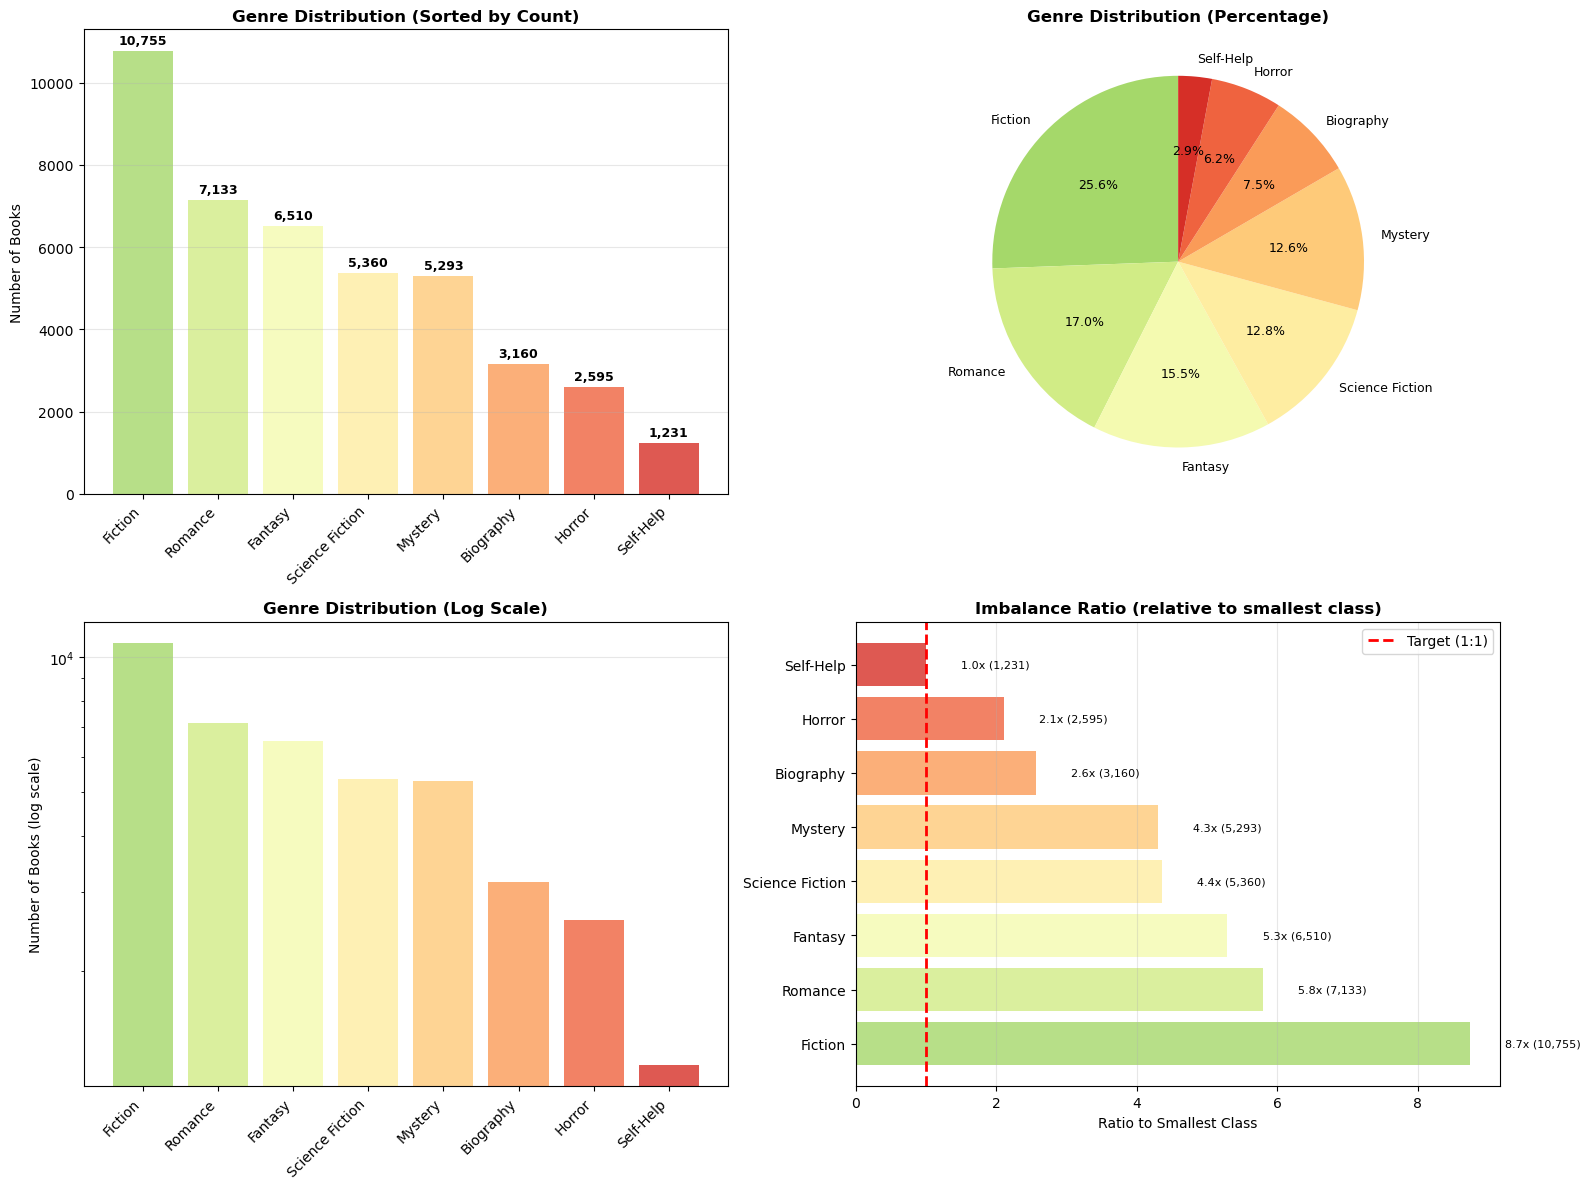


💡 Balancing Strategy:
   Smallest class: Self-Help with 1,231 books
   Recommended approach: Sample 1,231 books from each genre
   Final balanced dataset will have: 9,848 books

   Alternative: If 1,231 is too small, consider:
   - Using 1,846 per class (need more data for smallest)
   - Using 1,231 per class (reasonable size)


In [ ]:
print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)

# Counting books per genre
genre_counts = df['primary_genre'].value_counts().sort_values(ascending=False)

print(f"\nBooks per Genre:")
print(genre_counts)

# Calculating imbalance metrics
print(f"\n Imbalance Metrics:")
print(f"   Total books: {len(df):,}")
print(f"   Number of genres: {df['primary_genre'].nunique()}")
print(f"   Largest class: {genre_counts.iloc[0]:,} ({genre_counts.index[0]})")
print(f"   Smallest class: {genre_counts.iloc[-1]:,} ({genre_counts.index[-1]})")
print(f"   Imbalance ratio: {genre_counts.iloc[0] / genre_counts.iloc[-1]:.2f}x")
print(f"   Mean books per genre: {genre_counts.mean():.2f}")
print(f"   Median books per genre: {genre_counts.median():.2f}")
print(f"   Std deviation: {genre_counts.std():.2f}")

# Visualizing imbalance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart (sorted by count)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(genre_counts)))
axes[0, 0].bar(range(len(genre_counts)), genre_counts.values, color=colors, alpha=0.8)
axes[0, 0].set_xticks(range(len(genre_counts)))
axes[0, 0].set_xticklabels(genre_counts.index, rotation=45, ha='right')
axes[0, 0].set_title('Genre Distribution (Sorted by Count)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Books', fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Adding value labels
for i, v in enumerate(genre_counts.values):
    axes[0, 0].text(i, v + 100, f'{v:,}', ha='center', va='bottom', 
                     fontsize=9, fontweight='bold')

# 2. Pie chart
axes[0, 1].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90, textprops={'fontsize': 9})
axes[0, 1].set_title('Genre Distribution (Percentage)', fontsize=12, fontweight='bold')

# 3. Log scale bar chart 
axes[1, 0].bar(range(len(genre_counts)), genre_counts.values, color=colors, alpha=0.8)
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticks(range(len(genre_counts)))
axes[1, 0].set_xticklabels(genre_counts.index, rotation=45, ha='right')
axes[1, 0].set_title('Genre Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Books (log scale)', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Imbalance ratio visualization
smallest = genre_counts.min()
ratios = genre_counts.values / smallest
axes[1, 1].barh(range(len(genre_counts)), ratios, color=colors, alpha=0.8)
axes[1, 1].set_yticks(range(len(genre_counts)))
axes[1, 1].set_yticklabels(genre_counts.index)
axes[1, 1].set_title('Imbalance Ratio (relative to smallest class)', 
                      fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ratio to Smallest Class', fontsize=10)
axes[1, 1].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Target (1:1)')
axes[1, 1].legend()
axes[1, 1].grid(axis='x', alpha=0.3)

# Adding ratio labels
for i, (ratio, count) in enumerate(zip(ratios, genre_counts.values)):
    axes[1, 1].text(ratio + 0.5, i, f'{ratio:.1f}x ({count:,})', 
                     va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Determining balancing strategy
smallest_class_size = genre_counts.min()
print(f"\n💡 Balancing Strategy:")
print(f"   Smallest class: {genre_counts.index[-1]} with {smallest_class_size:,} books")
print(f"   Recommended approach: Sample {smallest_class_size:,} books from each genre")
print(f"   Final balanced dataset will have: {smallest_class_size * 8:,} books")

### Balancing DataSet 


DATASET BALANCING

 Balancing Strategy Options:
Using smallest class size (1,231 per genre)

 Selected Strategy: 1,231 books per genre
   Total balanced dataset: 9,848 books

Sampling Process:
   Fiction             : 10,755 →  1,231 Sampled
   Mystery             :  5,293 →  1,231 Sampled
   Romance             :  7,133 →  1,231 Sampled
   Science Fiction     :  5,360 →  1,231 Sampled
   Fantasy             :  6,510 →  1,231 Sampled
   Horror              :  2,595 →  1,231 Sampled
   Biography           :  3,160 →  1,231 Sampled
   Self-Help           :  1,231 →  1,231 Sampled

 Shuffling dataset...

 Balancing Complete:
   Before: 42,037 books (imbalanced)
   After: 9,848 books (balanced)
   Reduction: 32,189 books removed

 Balanced Distribution:
primary_genre
Biography          1231
Fantasy            1231
Fiction            1231
Horror             1231
Mystery            1231
Romance            1231
Science Fiction    1231
Self-Help          1231
Name: count, dtype: int64

 All ge

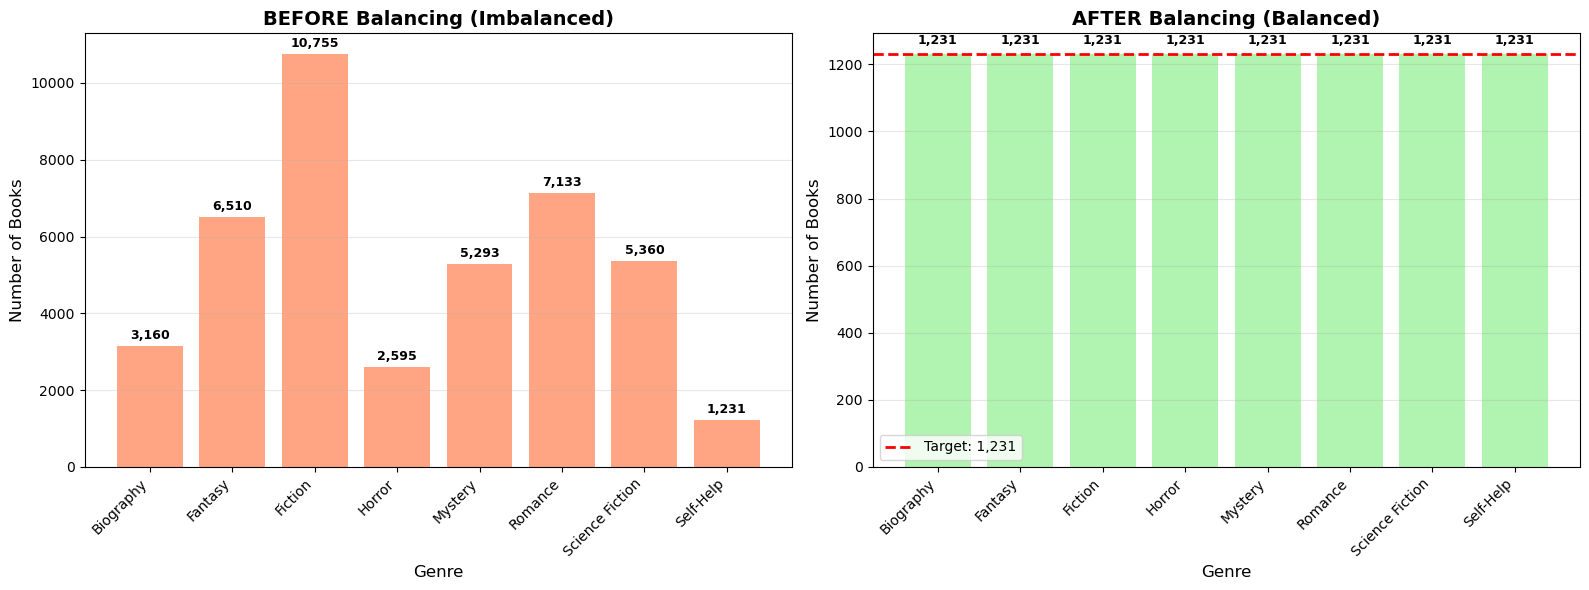

In [42]:
print("="*80)
print("DATASET BALANCING")
print("="*80)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Getting current distribution
genre_counts_before = df['primary_genre'].value_counts()
smallest_class_size = genre_counts_before.min()

# Balancing strategy
print(f"\n Balancing Strategy Options:")
print(f"Using smallest class size ({smallest_class_size:,} per genre)")



# Using smallest class (MOST BALANCED)
target_size_per_class = smallest_class_size


print(f"\n Selected Strategy: {target_size_per_class:,} books per genre")
print(f"   Total balanced dataset: {target_size_per_class * 8:,} books")

# Balancing the dataset
balanced_dfs = []
sampling_info = []

print(f"\nSampling Process:")
for genre in TARGET_GENRES:
    # Gettng all books of this genre
    genre_df = df[df['primary_genre'] == genre]
    available = len(genre_df)
    
    if available >= target_size_per_class:
        # Sampling the target size
        sampled = genre_df.sample(n=target_size_per_class, random_state=RANDOM_SEED)
        status = "Sampled"
        sampled_count = target_size_per_class
    else:
        # Taking all available (shouldn't happen if using smallest class)
        sampled = genre_df
        status = "Insufficient"
        sampled_count = available
    
    balanced_dfs.append(sampled)
    sampling_info.append({
        'Genre': genre,
        'Available': available,
        'Sampled': sampled_count,
        'Status': status
    })
    
    print(f"   {genre:20s}: {available:6,} → {sampled_count:6,} {status}")

# Combining all balanced samples
df_balanced = pd.concat(balanced_dfs, ignore_index=True)

print(f"\n Shuffling dataset...")
# Shuffle the dataset (mix genres randomly)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Verifying balance
genre_counts_after = df_balanced['primary_genre'].value_counts()

print(f"\n Balancing Complete:")
print(f"   Before: {len(df):,} books (imbalanced)")
print(f"   After: {len(df_balanced):,} books (balanced)")
print(f"   Reduction: {len(df) - len(df_balanced):,} books removed")

print(f"\n Balanced Distribution:")
print(genre_counts_after.sort_index())

# Verifying perfect balance
is_balanced = genre_counts_after.nunique() == 1
if is_balanced:
    print(f"\n All genres have exactly {target_size_per_class:,} books!")
else:
    print(f"\n Slight imbalance detected")

# Visualizing before vs after
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before balancing
axes[0].bar(range(len(genre_counts_before)), genre_counts_before.sort_index().values, 
            color='coral', alpha=0.7)
axes[0].set_xticks(range(len(genre_counts_before)))
axes[0].set_xticklabels(genre_counts_before.sort_index().index, rotation=45, ha='right')
axes[0].set_title('BEFORE Balancing (Imbalanced)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genre', fontsize=12)
axes[0].set_ylabel('Number of Books', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Addig value labels
for i, v in enumerate(genre_counts_before.sort_index().values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold')

# After balancing
axes[1].bar(range(len(genre_counts_after)), genre_counts_after.sort_index().values, 
            color='lightgreen', alpha=0.7)
axes[1].set_xticks(range(len(genre_counts_after)))
axes[1].set_xticklabels(genre_counts_after.sort_index().index, rotation=45, ha='right')
axes[1].axhline(y=target_size_per_class, color='red', linestyle='--', 
                linewidth=2, label=f'Target: {target_size_per_class:,}')
axes[1].set_title('AFTER Balancing (Balanced)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Genre', fontsize=12)
axes[1].set_ylabel('Number of Books', fontsize=12)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Adding value labels
for i, v in enumerate(genre_counts_after.sort_index().values):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', va='bottom', 
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Final Dataset Review

FINAL DATA QUALITY CHECKS

 Dataset Summary:
   Total books: 9,848
   Number of genres: 8
   Books per genre: 1,231

 Genre Distribution (Final):
   Biography           :  1,231 books
   Fantasy             :  1,231 books
   Fiction             :  1,231 books
   Horror              :  1,231 books
   Mystery             :  1,231 books
   Romance             :  1,231 books
   Science Fiction     :  1,231 books
   Self-Help           :  1,231 books

🔍 Missing Values Check:
description_clean    0
primary_genre        0
dtype: int64
 No missing values!

 Description Length Statistics:
   Mean length: 888.00 characters
   Median length: 819.00 characters
   Min length: 20 characters
   Max length: 8827 characters
   Std deviation: 540.02 characters
   25th percentile: 543.00 characters
   75th percentile: 1116.00 characters


/var/folders/16/8wbd_26j7s3_xg7_kjbychqc0000gn/T/ipykernel_41695/2511105670.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(desc_by_genre, labels=TARGET_GENRES)


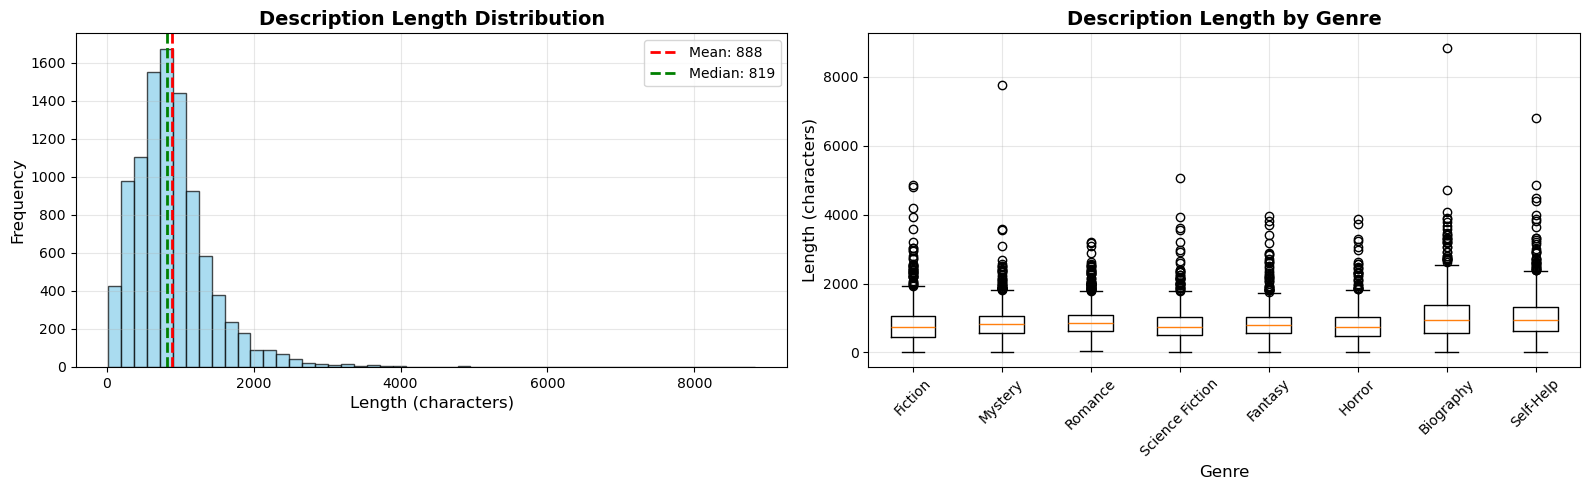


SAMPLE FROM EACH GENRE

Fiction:
   Title: Cat's Eye...
   Description (624 chars): 
   Cat's Eye is the story of Elaine Risley, a controversial painter who returns to Toronto, the city of her youth, for a retrospective of her art. Engulfed by vivid images of the past, she reminisces abo...
--------------------------------------------------------------------------------

Mystery:
   Title: Cop Town...
   Description (629 chars): 
   Atlanta, 1974.As a brutal killing rocks the city, Kate Murphy wonders if her first day on the police force will also be her last. For life is anything but easy in the male-dominated world of the Atlan...
--------------------------------------------------------------------------------

Romance:
   Title: Elements of Chemistry: Capture...
   Description (968 chars): 
   He broke her heart, and now he s back . . . From the New York Times Bestselling Author Penny ReidOne week. Manhattan apartment. Super-hot ex-boyfriend. What s the worst that could happen?It s

In [44]:
print("="*80)
print("FINAL DATA QUALITY CHECKS")
print("="*80)

print(f"\n Dataset Summary:")
print(f"   Total books: {len(df_balanced):,}")
print(f"   Number of genres: {df_balanced['primary_genre'].nunique()}")
print(f"   Books per genre: {len(df_balanced) // df_balanced['primary_genre'].nunique():,}")

print(f"\n Genre Distribution (Final):")
final_dist = df_balanced['primary_genre'].value_counts().sort_index()
for genre, count in final_dist.items():
    print(f"   {genre:20s}: {count:6,} books")

print(f"\n🔍 Missing Values Check:")
missing_check = df_balanced[['description_clean', 'primary_genre']].isnull().sum()
print(missing_check)
if missing_check.sum() == 0:
    print(" No missing values!")
else:
    print(" Warning: Missing values detected!")

print(f"\n Description Length Statistics:")
desc_lengths = df_balanced['description_clean'].str.len()
print(f"   Mean length: {desc_lengths.mean():.2f} characters")
print(f"   Median length: {desc_lengths.median():.2f} characters")
print(f"   Min length: {desc_lengths.min()} characters")
print(f"   Max length: {desc_lengths.max()} characters")
print(f"   Std deviation: {desc_lengths.std():.2f} characters")
print(f"   25th percentile: {desc_lengths.quantile(0.25):.2f} characters")
print(f"   75th percentile: {desc_lengths.quantile(0.75):.2f} characters")

# Visualizing description length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(desc_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(desc_lengths.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {desc_lengths.mean():.0f}')
axes[0].axvline(desc_lengths.median(), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {desc_lengths.median():.0f}')
axes[0].set_title('Description Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by genre
desc_by_genre = [df_balanced[df_balanced['primary_genre'] == g]['description_clean'].str.len() 
                 for g in TARGET_GENRES]
axes[1].boxplot(desc_by_genre, labels=TARGET_GENRES)
axes[1].set_title('Description Length by Genre', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Genre', fontsize=12)
axes[1].set_ylabel('Length (characters)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sample from each genre
print("\n" + "="*80)
print("SAMPLE FROM EACH GENRE")
print("="*80)

for genre in TARGET_GENRES:
    sample = df_balanced[df_balanced['primary_genre'] == genre].iloc[0]
    print(f"\n{genre}:")
    print(f"   Title: {sample['title'][:60]}...")
    print(f"   Description ({len(sample['description_clean'])} chars): ")
    print(f"   {sample['description_clean'][:200]}...")
    print("-" * 80)

### Preparing for ML Models 

In [45]:
print("="*80)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*80)

# Creating final features and labels
X = df_balanced['description_clean'].values  # Features (text descriptions)
y = df_balanced['primary_genre'].values      # Labels (genres)

print(f"\n Data Prepared:")
print(f"   Features (X): {X.shape} - Text descriptions")
print(f"   Labels (y): {y.shape} - Genre labels")

# Creating label encoding for later use
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n  Label Encoding:")
for idx, genre in enumerate(label_encoder.classes_):
    count = (y_encoded == idx).sum()
    print(f"   {idx}: {genre:20s} ({count:,} samples)")

# Show samples
print(f"\n Sample Data:")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"   Genre: {y[i]}")
    print(f"   Encoded: {y_encoded[i]}")
    print(f"   Description: {X[i][:150]}...")

# Storing encoding for later
df_balanced['genre_encoded'] = y_encoded

PREPARING DATA FOR MACHINE LEARNING

 Data Prepared:
   Features (X): (9848,) - Text descriptions
   Labels (y): (9848,) - Genre labels

  Label Encoding:
   0: Biography            (1,231 samples)
   1: Fantasy              (1,231 samples)
   2: Fiction              (1,231 samples)
   3: Horror               (1,231 samples)
   4: Mystery              (1,231 samples)
   5: Romance              (1,231 samples)
   6: Science Fiction      (1,231 samples)
   7: Self-Help            (1,231 samples)

 Sample Data:

Example 1:
   Genre: Horror
   Encoded: 3
   Description: On a soft summer night in Vermont, 12-year-old Lisa went into the woods behind her house and never came out again. Before she disappeared, she told he...

Example 2:
   Genre: Romance
   Encoded: 5
   Description: He broke her heart, and now he s back . . . From the New York Times Bestselling Author Penny ReidOne week. Manhattan apartment. Super-hot ex-boyfriend...

Example 3:
   Genre: Romance
   Encoded: 5
   Description:

### Saving Cleaned Data 

In [47]:
print("="*80)
print("SAVING CLEANED DATA")
print("="*80)

# Prepainge data for saving
# Keep only necessary columns for ML Models Training
columns_for_ml = ['title', 'description_clean', 'primary_genre', 'genre_encoded']
df_final = df_balanced[columns_for_ml].copy()

# Renaming  for clarity
df_final.columns = ['title', 'description', 'genre', 'genre_label']

# Saving to processed folder
OUTPUT_PATH = '../data/processed/cleaned_books_balanced.csv'

print(f"\nSaving to: {OUTPUT_PATH}")
df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f"\nData saved successfully!")
print(f"   File: {OUTPUT_PATH}")
print(f"   Total records: {len(df_final):,}")
print(f"   Columns: {df_final.columns.tolist()}")
print(f"   File size: {os.path.getsize(OUTPUT_PATH) / 1024**2:.2f} MB")

# Also saving genre encoding mapping for later use
genre_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\n🏷️ Genre Label Mapping:")
for genre, label in genre_mapping.items():
    print(f"   {label}: {genre}")

# Saving mapping as separate file for reference
import json
mapping_path = '../data/processed/genre_mapping.json'

# Ensuring  all values are native Python int
genre_mapping_int = {genre: int(idx) for genre, idx in genre_mapping.items()}

with open(mapping_path, 'w') as f:
    json.dump(genre_mapping_int, f, indent=2)
print(f"\nGenre mapping saved to: {mapping_path}")

# Displaying first few rows of saved data
print(f"\n📋 First 5 rows of saved data:")
print(df_final.head())

# Displaying statistics
print(f"\n📊 Final Dataset Statistics:")
print(f"   Total books: {len(df_final):,}")
print(f"   Genres: {df_final['genre'].nunique()}")
print(f"   Books per genre: {len(df_final) // df_final['genre'].nunique():,}")
print(f"   Avg description length: {df_final['description'].str.len().mean():.2f} chars")
print(f"   Min description length: {df_final['description'].str.len().min()} chars")
print(f"   Max description length: {df_final['description'].str.len().max()} chars")

SAVING CLEANED DATA

Saving to: ../data/processed/cleaned_books_balanced.csv

Data saved successfully!
   File: ../data/processed/cleaned_books_balanced.csv
   Total records: 9,848
   Columns: ['title', 'description', 'genre', 'genre_label']
   File size: 8.75 MB

🏷️ Genre Label Mapping:
   0: Biography
   1: Fantasy
   2: Fiction
   3: Horror
   4: Mystery
   5: Romance
   6: Science Fiction
   7: Self-Help

Genre mapping saved to: ../data/processed/genre_mapping.json

📋 First 5 rows of saved data:
                                               title  \
0                               Don't Breathe a Word   
1                     Elements of Chemistry: Capture   
2                                 Asking For Trouble   
3  Touched with Fire: Manic-Depressive Illness an...   
4                                 The Land of Laughs   

                                         description      genre  genre_label  
0  On a soft summer night in Vermont, 12-year-old...     Horror            3  
